# Exploratory Data Analysis
This notebook explores the multimodal dataset for retrieval task, analyzing text and image quote distributions, question characteristics, and modality statistics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from pathlib import Path
from collections import Counter

sns.set_theme(style="whitegrid")

## 1. Load Data

In [2]:
DATA_DIR = Path("../data")

def load_jsonl(path):
    with open(path, 'r', encoding='utf-8') as f:
        return [json.loads(line) for line in f]

train_data = load_jsonl(DATA_DIR / "train.jsonl")
test_data = load_jsonl(DATA_DIR / "test.jsonl")

print(f"Train samples: {len(train_data)}")
print(f"Test samples:  {len(test_data)}")

Train samples: 2055
Test samples:  1798


## 2. High-Level Statistics

In [3]:
df_train = pd.DataFrame(train_data)

# Calculate candidates per sample
df_train['num_text_quotes'] = df_train['text_quotes'].apply(len)
df_train['num_img_quotes'] = df_train['img_quotes'].apply(len)
df_train['total_candidates'] = df_train['num_text_quotes'] + df_train['num_img_quotes']
df_train['num_gold'] = df_train['gold_quotes'].apply(len)

print("\nSummary Statistics for Candidates per Sample:")
print(df_train[['num_text_quotes', 'num_img_quotes', 'total_candidates', 'num_gold']].describe().round(2))


Summary Statistics for Candidates per Sample:
       num_text_quotes  num_img_quotes  total_candidates  num_gold
count           2055.0         2055.00           2055.00   2055.00
mean              10.0            5.00             15.00      2.52
std                0.0            0.09              0.09      1.51
min               10.0            3.00             13.00      0.00
25%               10.0            5.00             15.00      1.00
50%               10.0            5.00             15.00      2.00
75%               10.0            5.00             15.00      3.00
max               10.0            7.00             17.00      9.00


## 3. Modality & Gold Distribution

/tmp/ipykernel_200262/669847192.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(modality_counts.keys()), y=list(modality_counts.values()), ax=axes[0], palette='viridis')
/tmp/ipykernel_200262/669847192.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='num_gold', data=df_train, ax=axes[1], palette='magma')


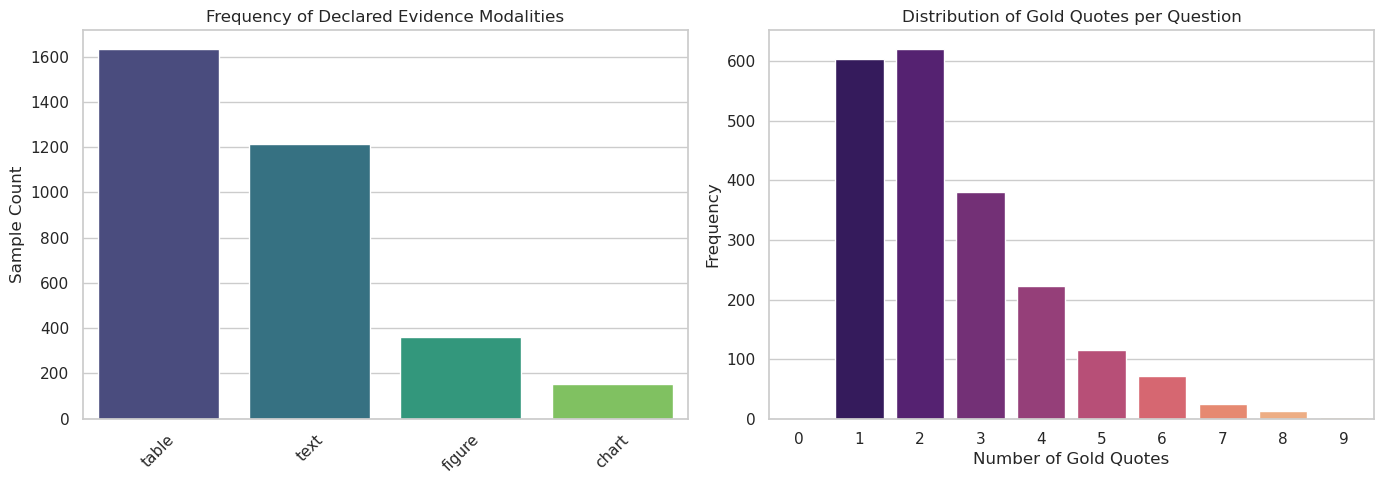

In [4]:
# Explode the modalities to count their frequency
all_modalities = []
for mods in df_train['evidence_modality_type']:
    all_modalities.extend(mods)

modality_counts = Counter(all_modalities)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Overall Evidence Modalities
sns.barplot(x=list(modality_counts.keys()), y=list(modality_counts.values()), ax=axes[0], palette='viridis')
axes[0].set_title("Frequency of Declared Evidence Modalities")
axes[0].set_ylabel("Sample Count")
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Gold Quote Counts per question
sns.countplot(x='num_gold', data=df_train, ax=axes[1], palette='magma')
axes[1].set_title("Distribution of Gold Quotes per Question")
axes[1].set_xlabel("Number of Gold Quotes")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 4. Gold Quotes Type Breakdown

Total gold Text items:  2058
Total gold Image items: 3118
Percentage of Image gold quotes: 60.24%


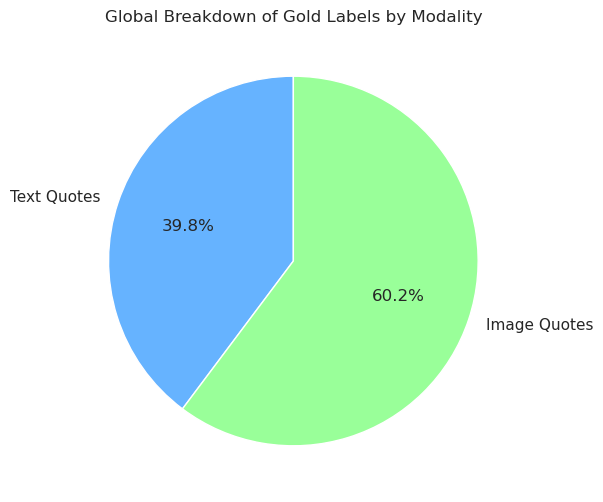

In [5]:
# Analyze how many gold quotes are image vs text
def analyze_gold_types(row):
    gold = set(row['gold_quotes'])
    text_ids = {q['quote_id'] for q in row['text_quotes']}
    img_ids = {q['quote_id'] for q in row['img_quotes']}
    
    n_text = len(gold.intersection(text_ids))
    n_img = len(gold.intersection(img_ids))
    return pd.Series([n_text, n_img], index=['gold_text_cnt', 'gold_img_cnt'])

df_gold_types = df_train.apply(analyze_gold_types, axis=1)
total_gold_text = df_gold_types['gold_text_cnt'].sum()
total_gold_img = df_gold_types['gold_img_cnt'].sum()

print(f"Total gold Text items:  {total_gold_text}")
print(f"Total gold Image items: {total_gold_img}")
print(f"Percentage of Image gold quotes: {total_gold_img / (total_gold_text + total_gold_img) * 100:.2f}%")

plt.figure(figsize=(6, 6))
plt.pie([total_gold_text, total_gold_img], labels=['Text Quotes', 'Image Quotes'], 
        autopct='%1.1f%%', colors=['#66b3ff','#99ff99'], startangle=90)
plt.title("Global Breakdown of Gold Labels by Modality")
plt.show()

## 5. Candidate Length Analysis

Average Text Quote length: 460.2 characters
Average Image Description length: 923.7 characters


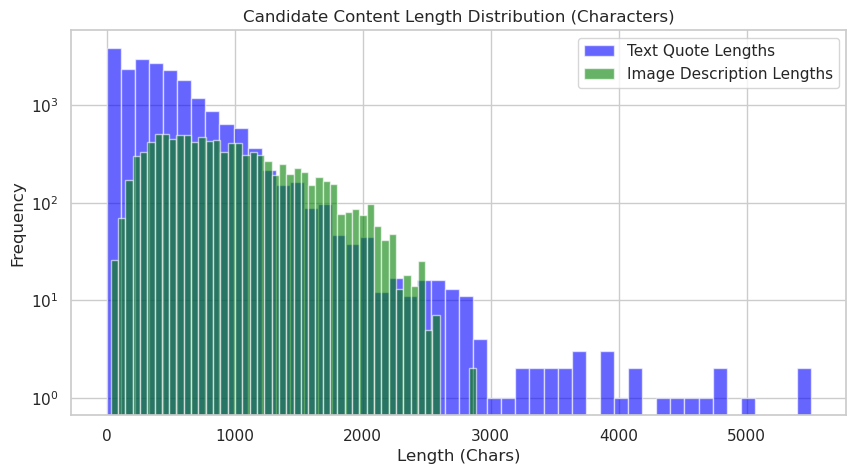

In [6]:
# Calculate character length statistics for texts vs image descriptions
text_lengths = []
for quotes in df_train['text_quotes']:
    text_lengths.extend([len(q['text']) for q in quotes])

img_desc_lengths = []
for quotes in df_train['img_quotes']:
    img_desc_lengths.extend([len(q['img_description']) for q in quotes if q.get('img_description')])

print(f"Average Text Quote length: {np.mean(text_lengths):.1f} characters")
print(f"Average Image Description length: {np.mean(img_desc_lengths):.1f} characters")

plt.figure(figsize=(10, 5))
plt.hist(text_lengths, bins=50, alpha=0.6, label='Text Quote Lengths', color='blue')
plt.hist(img_desc_lengths, bins=50, alpha=0.6, label='Image Description Lengths', color='green')
plt.title("Candidate Content Length Distribution (Characters)")
plt.xlabel("Length (Chars)")
plt.ylabel("Frequency")
plt.yscale('log') # Use log scale because text lengths can be high skew
plt.legend()
plt.show()

## 6. Path Validation
Verifying images exist on disk.

In [7]:
missing_images = []
sample_check = df_train.head(100)

for idx, quotes in sample_check['img_quotes'].items():
    for q in quotes:
        p = DATA_DIR / q['img_path']
        if not p.exists():
            missing_images.append(str(p))

if missing_images:
    print(f"Warning: Found {len(missing_images)} missing image paths in the sample check.")
else:
    print("✅ All sampled image paths verified successfully.")